In [1]:
from preamble import *

2025-06-01 19:13:22,237 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [2]:
from matplotlib.animation import PillowWriter

In [3]:
# S22_radii = jnp.array([
#     0.039618, 0.034566, 0.043403, 0.044040, 0.043135,
#     0.037270, 0.042707, 0.040468, 0.043164, 0.042035,
#     0.037215, 0.041515, 0.040428, 0.042082, 0.042750
# ])
# S22_uncertainties = jnp.array([[
#     0.000784, 0.001179, 0.000275, 0.000246, 0.000362,
#     0.000539, 0.000311, 0.001018, 0.000466, 0.000515,
#     0.000468, 0.000285, 0.000382, 0.000480, 0.000452
# ],
#            [
#     0.0007264, 0.0005629, 0.0003175, 0.0002488, 0.0004818,
#     0.0004355, 0.0002766, 0.0005623, 0.0004208, 0.0003845,
#     0.0003517, 0.0003176, 0.0004346, 0.0005546, 0.0007410
# ]])

# F21_radii = jnp.array([0.041441, 0.037986, 0.041139, 0.040237, 0.040276,
#     0.039406, 0.041164, 0.041957, 0.044769])
# F21_uncertainties = jnp.array([[0.000457, 0.000353, 0.000348, 0.000388, 0.000344,
#     0.000293, 0.000347, 0.000382, 0.000358],
#            [0.0003811, 0.0003123, 0.0003040, 0.0004352, 0.0003653,
#     0.0002596, 0.0003782, 0.0002836, 0.0003250]])

# wavelength_bins = S22_bin_edges
# S22wavelengths = (wavelength_bins[1:]-wavelength_bins[:-1])/2 + wavelength_bins[:-1]
# wavelength_bins = F21_bin_edges
# F21wavelengths = (wavelength_bins[1:]-wavelength_bins[:-1])/2 + wavelength_bins[:-1]

# plt.errorbar(S22wavelengths, S22_radii**2*1e6, yerr=2*S22_uncertainties*S22_radii*1e6, xerr=S22wavelengths-S22_bin_edges[:-1],
#              fmt='o',color='b',alpha=0.7,ms=3,label='G102')
# plt.errorbar(F21wavelengths, F21_radii**2*1e6, yerr=2*F21_uncertainties*F21_radii*1e6, xerr=F21wavelengths-F21_bin_edges[:-1],
#              fmt='o',color='r',alpha=0.7,ms=3,label='G141')

# plt.ylabel('Transit Depth (ppm)')
# plt.xlabel(r'Wavelength ($\mu$m)')
# plt.legend(loc='lower right')
# plt.title('De-Contaminated Transmission Spectrum')
# plt.savefig('Decontaminated_Transmission.png',dpi=300)

In [13]:
default_params={
    # Fixed parameters
    "log_g":4.52,
    "P_orb":8.463,
    "stellar_i":85.0,
    'P_rot':4.86,
    "Rs":0.8,
    "Ms":0.6,
    "Mp":12.0,
    "metallicity":0.12,
    "planet_i":89.5,
    "HST_period":0.066,
    # Ramp Model Parameters
    "r1": 18,
    "r2": -7,
    "r3": 0,
    #Breathing params
    "b1":0,
    "b2":0,
    "b3":0,
    "b4":0,
    # Transit Parameters
    "u1":0.22,
    "u2":0.35,
    "T_0":0.0,
    "Rp_Rs_broadband": 0.04,
    "a_rstar": 18.2,
    "T_ref":600,
    "ecc": 0.045,
    # Transmission Parameters
    "log_fixedspot_radii":-1.6,
    "f_spot":0.2,
    "spec_scale_factor": 1.0,
    # Stellar Parameters
    "T_phot": 4100,
    "T_unocculted": 3100,
    "T_occulted": 3400,
    "spot1_lon":-1.1,
    "spot1_lat":1.2,
    "spot1_rad":0.2,
    "spot2_lon":0.875,
    "spot2_lat":1.79,
    "spot2_rad":0.07,
    # "spot3_lon":0.09,
    # "spot3_lat":1.48,
    # "spot3_rad":0.32,
}

'Initialization'
n_spots = 2
n_fixedspots = 0#800

'Set the binning'
orbits_to_exclude = np.array([0])
orbits_to_include = np.array([1,2,3,4,5,6,7])

model_wavelengths = jnp.linspace(0.4,4,500)#*u.micron

_cool_unocculted = get_BTSettl_spectrum_jax(T=jnp.array(3100) )
_cool_occulted = get_BTSettl_spectrum_jax(T=jnp.array(3400) )
_phot = get_BTSettl_spectrum_jax(T=jnp.array(4000) )
Cool_unocculted = bin_spectrum(output_wavelength = model_wavelengths,
                    input_wavelength = _cool_unocculted[0],
                    input_flux = _cool_unocculted[1])
Cool_occulted = bin_spectrum(output_wavelength = model_wavelengths,
                    input_wavelength = _cool_occulted[0],
                    input_flux = _cool_occulted[1])
Phot = bin_spectrum(output_wavelength = model_wavelengths,
                    input_wavelength = _phot[0],
                    input_flux = _phot[1])

planet_parameters = dict(
    inclination = np.radians(default_params['planet_i']),
    a = default_params['a_rstar'],
    rp = 0.044,
    period = default_params['P_orb'],
    t0 = 0,
    # omega = np.radians(88.5),
    ecc = default_params['ecc'],
    u1 = np.linspace(0.4,0.1,len(model_wavelengths)),
    u2 = np.linspace(0.2,0.45,len(model_wavelengths)),)

notrans_planet_parameters = dict(
    inclination = np.radians(default_params['planet_i']),
    a = default_params['a_rstar'],
    rp = 0.0,
    period = default_params['P_orb'],
    t0 = 0,
    # omega = np.radians(88.5),
    ecc = default_params['ecc'],
    u1 = np.linspace(0.4,0.1,len(model_wavelengths)),
    u2 = np.linspace(0.2,0.45,len(model_wavelengths)),)

active_star = ActiveStar(
    times=jnp.linspace(-0.2,0.2,1000),
    inclination=jnp.radians(default_params['stellar_i']),  # stellar inc [rad]
    T_eff=default_params['T_phot'],
    wavelength=model_wavelengths/1e4, #use data wavelength array
    phot=Phot, #This is the model spectrum for the photosphere temp
    P_rot=default_params['P_rot'])

for i in range(1, n_fixedspots + 1):
    # Generate random values within the parameter space for each spot
    lon = np.random.uniform(-2.8,2.8)
    lat = random.choice( [np.random.beta(2, 1)*(0.9 - 0.1) + 0.1, np.random.beta(1,2)*(3.04 - 2.24) + 2.24 ] )
    rad = 0.01

    latspot = dict(
        lon=lon,  # Longitude [rad]
        lat=lat,  # Latitude [rad]
        rad=rad,  # Radius [R_star]
        spectrum=Cool_unocculted,  # Use provided spectrum
        temperature=default_params['T_unocculted'],  # Use provided temperature
    )
    # Add the spot to the active star
    active_star.add_spot(**latspot)
    
unocculted_lon = default_params[f"spot1_lon"]
unocculted_lat = default_params[f"spot1_lat"]
unocculted_rad = default_params[f"spot1_rad"]
spot = dict(
    lon=unocculted_lon,  # Longitude [rad]
    lat=unocculted_lat,  # Latitude [rad]
    rad=unocculted_rad,  # Radius [R_star]
    spectrum=Cool_unocculted,  # Use provided spectrum
    temperature=default_params['T_unocculted'],  # Use provided temperature
)
active_star.add_spot(**spot)

occulted_lon = default_params[f"spot2_lon"]
occulted_lat = default_params[f"spot2_lat"]
occulted_rad = default_params[f"spot2_rad"]
spot = dict(
    lon=occulted_lon,  # Longitude [rad]
    lat=occulted_lat,  # Latitude [rad]
    rad=occulted_rad,  # Radius [R_star]
    spectrum=Cool_occulted,  # Use provided spectrum
    temperature=default_params['T_occulted'],  # Use provided temperature
)
active_star.add_spot(**spot)

# for i in range(0,len(model_wavelengths)):
#     # 'Plot the stellar surface'
#     active_star.plot_star(
#         t0=planet_parameters['t0'],
#         rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
#         a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
#         inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
#         ecc=planet_parameters['ecc'],wl_bin = i)
#     plt.title(f'{model_wavelengths[i]:.4f}'+r'$\mu$m')
#     plt.show()
#     plt.clf()

/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_55126/2727381076.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


GIF created successfully!


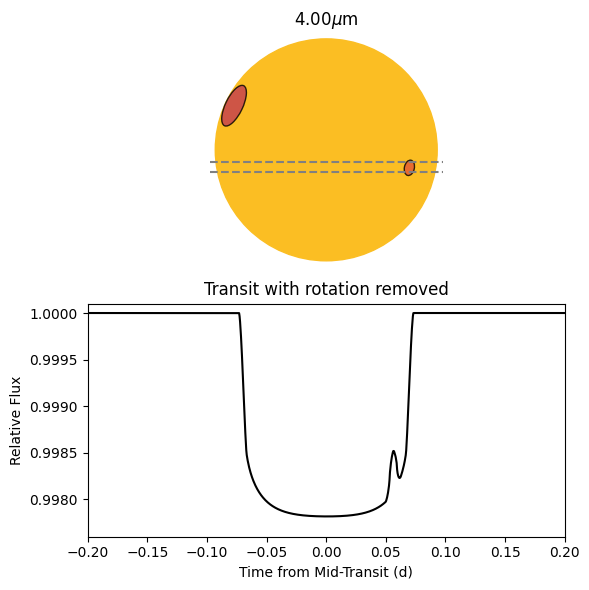

In [16]:
# Set up the 2-panel figure
fig,axes = plt.subplots(2,1,figsize=(6, 6), dpi=100)

starmap_ax = axes[0]
transit_ax = axes[1]

writer = PillowWriter(fps=50)

times = np.linspace(-0.2,0.2,1000)

'Update Stellar Parameters'
# active_star.times = times

lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
notrans_model, contam, X, Y, spectrum_at_transit = active_star.transit_model(**notrans_planet_parameters)
rotation_spectrum = active_star.rotation_spectrum()

with writer.saving(fig, 'spectral_contrasts.gif', dpi=100):

    for i,wl in enumerate(model_wavelengths):
        for ax in [transit_ax, starmap_ax]:
            ax.clear()
        
        'Lower Plot - Transit'
        lc_i = lcmodel.T[i]
        rotation_i = notrans_model.T[i]
        transit_ax.plot(times, lc_i/rotation_i,
                        color='k')
                        
        'Upper Plot - stellar surface'
        active_star.plot_star(
            t0=planet_parameters['t0'],
            rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
            a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
            inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
            ecc=planet_parameters['ecc'],
            wl_bin = i,
            ax=starmap_ax)
        starmap_ax.set_title(f'{model_wavelengths[i]:.2f}'+r'$\mu$m')

        transit_ax.set_title(r'Transit with rotation removed')
        transit_ax.set_xlabel('Time from Mid-Transit (d)')
        transit_ax.set_ylabel('Relative Flux')
        transit_ax.set_xlim(-0.2,0.2)
        transit_ax.set_ylim(0.9976,1.0001)

        plt.tight_layout()
        
        writer.grab_frame()

print("GIF created successfully!")

/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_66717/3884598831.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


GIF created successfully!


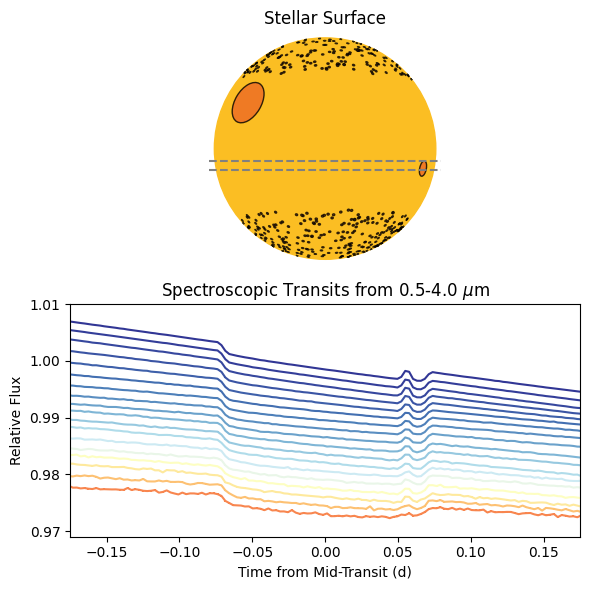

In [129]:
# Set up the 2-panel figure
fig,axes = plt.subplots(2,1,figsize=(6, 6), dpi=100)

starmap_ax = axes[0]
transit_ax = axes[1]

writer = PillowWriter(fps=15)

times = np.linspace(-0.2,0.2,150)

'Update Stellar Parameters'
active_star.times = times

lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

with writer.saving(fig, 'rotatingspectransits.gif', dpi=100):

    for i,time in enumerate(times):
        for ax in [transit_ax, starmap_ax]:
            ax.clear()
        
        'Lower Plot - Transit'
        for j, lc_j in enumerate(lcmodel.T):
            jitter = np.random.normal(0,jitter_sigma[j],lc_j.shape)
            lc_j = lc_j + jitter
            transit_ax.errorbar(times[:i], lc_j[:i]/lc_j.mean()-0.0015*j, yerr = jitter_sigma[j], ms=0.5,
                            color=plt.cm.RdYlBu_r((model_wavelengths[j] - model_wavelengths.min()) / np.ptp(model_wavelengths)))
        
        'Upper Plot - stellar surface'
        active_star.plot_star(
            t0=time,
            rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
            a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
            inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
            ecc=planet_parameters['ecc'],
            wl_bin = 0,
            ax=starmap_ax)

        # Calculate the position of the moving circle (from -0.2 to 0.2)
        circle_x = np.interp(i, [0, len(times)-1], [-2.9, 2.78])
        # Add the moving black circle
        # atm_circle = plt.Circle((circle_x, -0.155), 0.052, color='skyblue')  # Adjust radius (0.01) as needed
        # starmap_ax.add_patch(atm_circle)
        circle = plt.Circle((circle_x, -0.155), 0.045, color='black')  # Adjust radius (0.01) as needed
        starmap_ax.add_patch(circle)

        starmap_ax.set_title('Stellar Surface')
        starmap_ax.set_facecolor('black')
        transit_ax.set_title(r'Spectroscopic Transits from 0.5-4.0 $\mu$m')
        transit_ax.set_xlabel('Time from Mid-Transit (d)')
        transit_ax.set_ylabel('Relative Flux')
        transit_ax.set_xlim(-0.175,0.175)
        transit_ax.set_ylim(0.969,1.01)

        plt.tight_layout()
        
        writer.grab_frame()

print("GIF created successfully!")

## GIF FOR SPOT PARAMS

GIF created successfully!


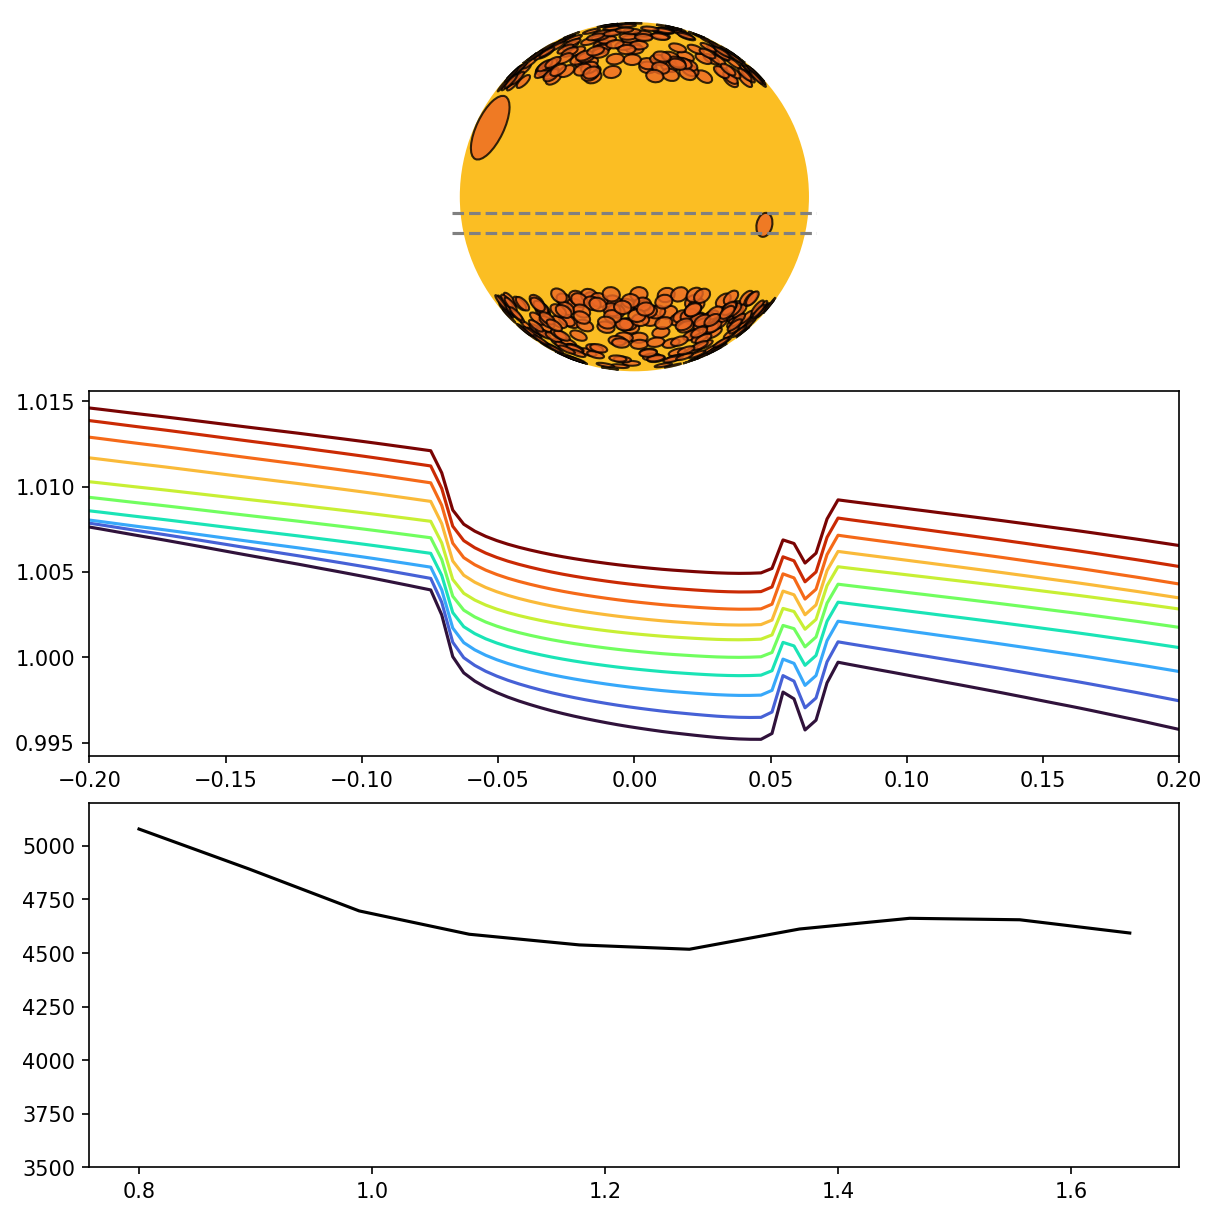

In [64]:
# Set up the 2-panel figure
fig,axes = plt.subplots(3,1,figsize=(8, 8), dpi=150)

starmap_ax = axes[0]
# starspec_ax = axes[0,1]
transit_ax = axes[1]
contam_ax = axes[2]

starmap_ax.set_title('Stellar Surface')
# starspec_ax.set_title('Stellar Spectrum')
# starspec_ax.set_xlabel('Wavelength (micron)')
# starspec_ax.set_ylabel('Flux')
transit_ax.set_title('Spectroscopic Transits')
transit_ax.set_xlabel('Time from Mid-Transit (d)')
transit_ax.set_ylabel('Relative Flux')
transit_ax.set_ylim(0.98,1.01)
contam_ax.set_title('Contamination')
contam_ax.set_ylabel('Depth (ppm)')
contam_ax.set_xlabel('Wavelength (micron)')
starmap_ax.set_facecolor('black')

writer = PillowWriter(fps=20)

times = np.linspace(-0.2,0.2,100)
spot_sizes = np.linspace(0,0.05,100)

'Update Stellar Parameters'
active_star.times = times
active_star.phot = Phot
active_star.wavelength = jnp.array(model_wavelengths/1e4)
active_star.spectrum = jnp.array([Cool] * (n_spots+n_fixedspots))
# active_star.T_eff = default_params['T_phot']
# active_star.temperature = jnp.array([default_params["T_spot"]] * (n_spots+n_fixedspots))
active_star.rad = jnp.array([0.0] * (n_spots+n_fixedspots))
# active_star.lon = active_star.lon.at[-n_spots:].set([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)][::-1])
# active_star.lat = active_star.lat.at[-n_spots:].set([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)][::-1])
active_star.rad = active_star.rad.at[-n_spots:].set([default_params[f"spot{i}_rad"] for i in range(1, n_spots + 1)][::-1])

lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

# contam_breakdown_ax.plot(model_wavelengths, contam, color='k')

with writer.saving(fig, 'four_panel_animation_fspot.gif', dpi=150):

    for i,rspot in enumerate(spot_sizes):
        for ax in [transit_ax, starmap_ax, contam_ax]:
            ax.clear()

        starmap_ax.set_facecolor('black')

        transit_ax.set_xlim(-0.2,0.2)
        contam_ax.set_ylim(0.0035*1e6,0.0052*1e6)

        active_star.rad = jnp.array([rspot] * (n_spots+n_fixedspots))
        # active_star.lon = active_star.lon.at[-n_spots:].set([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)][::-1])
        # active_star.lat = active_star.lat.at[-n_spots:].set([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)][::-1])
        active_star.rad = active_star.rad.at[-n_spots:].set([default_params[f"spot{i}_rad"] for i in range(1, n_spots + 1)][::-1])
        
        lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

        'Lower Left Plot - Transit'
        for j, lc_j in enumerate(lcmodel.T): 
            transit_ax.plot(times, lc_j/lc_j.mean()+0.001*j,
                            color=plt.cm.turbo((model_wavelengths[j] - model_wavelengths.min()) / np.ptp(model_wavelengths)))

        'bottom plot - contam'
        contam_ax.plot(model_wavelengths, contam*1e6,
                       color='k')

        'Upper Left Plot - stellar surface'
        active_star.plot_star(
            t0=0,
            rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
            a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
            inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
            ecc=planet_parameters['ecc'], ax=starmap_ax)
                
        writer.grab_frame()

print("GIF created successfully!")

In [ ]:
# Set up the 2-panel figure
fig,axes = plt.subplots(2,1,figsize=(8, 6), dpi=150)

starmap_ax = axes[0]
# starspec_ax = axes[0,1]
transit_ax = axes[1]
# contam_breakdown_ax = axes[2]

starmap_ax.set_title('Stellar Surface')
# starspec_ax.set_title('Stellar Spectrum')
# starspec_ax.set_xlabel('Wavelength (micron)')
# starspec_ax.set_ylabel('Flux')
transit_ax.set_title('Spectroscopic Transits')
transit_ax.set_xlabel('Time from Mid-Transit (d)')
transit_ax.set_ylabel('Relative Flux')
transit_ax.set_ylim(0.98,1.01)
# contam_breakdown_ax.set_title('Contamination')
# contam_breakdown_ax.set_ylabel('Depth (ppm)')
# contam_breakdown_ax.set_xlabel('Wavelength (micron)')
starmap_ax.set_facecolor('black')

writer = PillowWriter(fps=20)

times = np.linspace(-0.2,0.2,100)
spot_sizes = np.linspace(0,0.05,100)

'Update Stellar Parameters'
active_star.times = times
active_star.phot = Phot
active_star.wavelength = jnp.array(model_wavelengths/1e4)
active_star.spectrum = jnp.array([Cool] * (n_spots+n_fixedspots))
# active_star.T_eff = default_params['T_phot']
# active_star.temperature = jnp.array([default_params["T_spot"]] * (n_spots+n_fixedspots))
active_star.rad = jnp.array([0.01] * (n_spots+n_fixedspots))
# active_star.lon = active_star.lon.at[-n_spots:].set([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)][::-1])
# active_star.lat = active_star.lat.at[-n_spots:].set([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)][::-1])
active_star.rad = active_star.rad.at[-n_spots:].set([default_params[f"spot{i}_rad"] for i in range(1, n_spots + 1)][::-1])

lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

# contam_breakdown_ax.plot(model_wavelengths, contam, color='k')

with writer.saving(fig, 'four_panel_animation_fspot.gif', dpi=150):

    for i,Tspot in enumerate(spot_temps):
        for ax in [transit_ax, starmap_ax]:
            ax.clear()

        starmap_ax.set_facecolor('black')

        transit_ax.set_xlim(-0.1,0.1)
        transit_ax.set_ylim(0.985,1.015)

        active_star.rad = jnp.array([rspot] * (n_spots+n_fixedspots))
        # active_star.lon = active_star.lon.at[-n_spots:].set([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)][::-1])
        # active_star.lat = active_star.lat.at[-n_spots:].set([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)][::-1])
        active_star.rad = active_star.rad.at[-n_spots:].set([default_params[f"spot{i}_rad"] for i in range(1, n_spots + 1)][::-1])
        

        lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

        'Lower Left Plot - Transit'
        for j, lc_j in enumerate(lcmodel.T): 
            transit_ax.plot(times, lc_j/lc_j.mean()+0.001*j,
                            color=plt.cm.turbo((model_wavelengths[j] - model_wavelengths.min()) / np.ptp(model_wavelengths)))

        'Upper Left Plot - stellar surface'
        active_star.plot_star(
            t0=0,
            rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
            a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
            inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
            ecc=planet_parameters['ecc'], ax=starmap_ax)
        
        contam_breakdown_ax.plot(model_wavelengths,contam)
        
        writer.grab_frame()

print("GIF created successfully!")